# Expert Routing Accuracy Analysis

This notebook analyzes routing accuracy for specific languages by comparing actual routing decisions against expected expert assignments.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

Specify the path to your routing matrix file and the languages you want to analyze.

In [10]:
# Path to routing_matrix.npz file
ROUTING_DATA_PATH = "/scratch/hpc-prf-merlin/project_data/moe_study/extended_analysis/samples_100/hydra_hydra-exp-lpr_20260108_054502/checkpoint-95000_adapter/routing_matrix.npz"

# Language codes to analyze (comma-separated)
# Examples: acm_Arab, ary_Arab, bel_Cyrl, hin_Deva, eng_Latn, fra_Latn, deu_Latn, spa_Latn
# LANGUAGE_CODES = [
#     "eng_Latn",
#     "fra_Latn",
#     "deu_Latn",
#     "spa_Latn",
#     "rus_Cyrl"
# ]

# LANGUAGE_CODES = [
#     "mya_Mymr",
#     "bod_Tibt",
#     "lus_Latn",
#     "dzo_Tibt",
#     "new_Deva",
#     "kac_Latn"
# ]

# LANGUAGE_CODES = [
#     "hun_Latn",
#     "fin_Latn",
#     "sme_Latn",
#     "udm_Cyrl",
#     "mhr_Cyrl"
# ]

# LANGUAGE_CODES = [
#     "arb_Arab",
#     "heb_Hebr",
#     "mlt_Latn",
#     "som_Latn",
#     "aeb_Arab"
# ]

# LANGUAGE_CODES = [
#     "jpn_Jpan",
#     "vie_Latn",
#     "kor_Hang",
#     "nob_Latn",
#     "ekk_Latn",
#     "tam_Latn",
#     "kat_Geor",
#     "mal_Latn",
#     "kan_Knda",
#     "tel_Latn",
#     "khm_Khmr",
#     "eus_Latn",
#     "nno_Latn",
#     "epo_Latn",
#     "mww_Latn",
#     "kal_Latn",
#     "kha_Latn"
# ]

# LANGUAGE_CODES = [
#     "tha_Thai",
#     "lao_Laoo",
#     "shn_Mymr"
# ]

LANGUAGE_CODES = [
    "acm_Arab",
    "ady_Cyrl",
    "aeb_Arab",
    "afr_Latn",
    "als_Latn",
    "amh_Ethi",
    "apc_Arab",
    "arb_Arab",
    "arg_Latn",
    "ars_Arab",
    "ary_Arab",
    "arz_Arab",
    "asm_Beng",
    "ast_Latn",
    "ava_Cyrl",
    "azb_Arab",
    "bak_Cyrl",
    "ban_Latn",
    "bar_Latn",
    "bcl_Latn",
    "bel_Cyrl",
    "ben_Beng",
    "bew_Latn",
    "bho_Deva",
    "bod_Tibt",
    "bos_Latn",
    "bre_Latn",
    "bul_Cyrl",
    "bxr_Cyrl",
    "cat_Latn",
    "ceb_Latn",
    "ces_Latn",
    "che_Cyrl",
    "chv_Cyrl",
    "ckb_Arab",
    "cos_Latn",
    "crh_Cyrl",
    "cym_Latn",
    "dan_Latn",
    "deu_Latn",
    "diq_Latn",
    "div_Thaa",
    "dsb_Latn",
    "dzo_Tibt",
    "ekk_Latn",
    "ell_Grek",
    "eng_Latn",
    "epo_Latn",
    "eus_Latn",
    "ewe_Latn",
    "fao_Latn",
    "fij_Latn",
    "fin_Latn",
    "fra_Latn",
    "fry_Latn",
    "fur_Latn",
    "gaz_Latn",
    "gla_Latn",
    "gle_Latn",
    "glg_Latn",
    "glk_Arab",
    "grc_Grek",
    "gsw_Latn",
    "guj_Gujr",
    "hat_Latn",
    "haw_Latn",
    "hbo_Hebr",
    "heb_Hebr",
    "hif_Latn",
    "hil_Latn",
    "hin_Deva",
    "hne_Deva",
    "hrv_Latn",
    "hsb_Latn",
    "hun_Latn",
    "hye_Armn",
    "iba_Latn",
    "ibo_Latn",
    "ido_Latn",
    "ilo_Latn",
    "ind_Latn",
    "inh_Cyrl",
    "isl_Latn",
    "ita_Latn",
    "jav_Latn",
    "jpn_Jpan",
    "kab_Latn",
    "kac_Latn",
    "kal_Latn",
    "kan_Knda",
    "kat_Geor",
    "kaz_Cyrl",
    "kbd_Cyrl",
    "kha_Latn",
    "khk_Cyrl",
    "khm_Khmr",
    "kik_Latn",
    "kin_Latn",
    "kir_Cyrl",
    "kmr_Cyrl",
    "kor_Hang",
    "kpv_Cyrl",
    "lao_Laoo",
    "lat_Latn",
    "lez_Cyrl",
    "lim_Latn",
    "lin_Latn",
    "lit_Latn",
    "lmo_Latn",
    "ltg_Latn",
    "ltz_Latn",
    "lug_Latn",
    "lus_Latn",
    "mai_Deva",
    "mal_Latn",
    "mar_Deva",
    "mfe_Latn",
    "mhr_Cyrl",
    "mkd_Cyrl",
    "mlt_Latn",
    "mri_Latn",
    "mww_Latn",
    "mya_Mymr",
    "myv_Cyrl",
    "nap_Latn",
    "nde_Latn",
    "ndo_Latn",
    "nds_Latn",
    "new_Deva",
    "nld_Latn",
    "nno_Latn",
    "nob_Latn",
    "npi_Deva",
    "nrm_Latn",
    "nya_Latn",
    "oci_Latn",
    "ory_Latn",
    "oss_Cyrl",
    "pan_Guru",
    "pap_Latn",
    "pbt_Arab",
    "plt_Latn",
    "pms_Latn",
    "pnb_Arab",
    "pol_Latn",
    "por_Latn",
    "rmy_Cyrl",
    "roh_Latn",
    "ron_Cyrl",
    "rue_Cyrl",
    "run_Latn",
    "rus_Cyrl",
    "sah_Cyrl",
    "san_Deva",
    "scn_Latn",
    "sco_Latn",
    "sdh_Arab",
    "shn_Mymr",
    "sin_Sinh",
    "slk_Latn",
    "slv_Latn",
    "sme_Latn",
    "smo_Latn",
    "sna_Latn",
    "snd_Arab",
    "som_Latn",
    "sot_Latn",
    "spa_Latn",
    "srd_Latn",
    "srp_Cyrl",
    "sun_Latn",
    "swe_Latn",
    "swh_Latn",
    "tam_Latn",
    "tat_Cyrl",
    "tel_Latn",
    "tgk_Cyrl",
    "tha_Thai",
    "tir_Ethi",
    "ton_Latn",
    "tso_Latn",
    "tuk_Arab",
    "tur_Latn",
    "tyv_Cyrl",
    "udm_Cyrl",
    "uig_Arab",
    "ukr_Cyrl",
    "urd_Arab",
    "uzn_Cyrl",
    "vie_Latn",
    "vls_Latn",
    "vro_Latn",
    "wln_Latn",
    "wol_Latn",
    "xho_Latn",
    "ydd_Hebr",
    "yor_Latn",
    "zea_Latn",
    "zsm_Arab",
    "zul_Latn"
]

## Load Routing Data

In [ ]:
# Load the routing matrix file
print(f"Loading routing data from: {ROUTING_DATA_PATH}")
data = np.load(ROUTING_DATA_PATH, allow_pickle=True)

# Extract data
routing_matrix = data['routing_matrix']  # [num_langs, num_layers, num_experts]
all_languages = data['languages'].tolist()
num_layers = int(data['num_layers'])
num_experts = int(data['num_experts'])
router_mode = str(data.get('router_mode', 'unknown'))

# Check for target routing matrix
if 'target_routing_matrix' not in data or not data.get('has_target_routing', False):
    raise ValueError(
        "No target routing matrix found! The routing analysis must be run with --use_language_ids."
    )

target_routing_matrix = data['target_routing_matrix']

print(f"Loaded data:")
print(f"  - Total languages: {len(all_languages)}")
print(f"  - Layers: {num_layers}")
print(f"  - Experts: {num_experts}")
print(f"  - Router mode: {router_mode}")

Loading routing data from: /scratch/hpc-prf-merlin/project_data/moe_study/extended_analysis/samples_100/hydra_hydra-exp-lpr_20260108_054502/checkpoint-95000_adapter/routing_matrix.npz
✓ Loaded data:
  - Total languages: 200
  - Layers: 32
  - Experts: 11
  - Router mode: learned


## Compute Routing Accuracy for Specified Languages

In [ ]:
def compute_language_accuracy(lang_code, lang_idx):
    """Compute routing accuracy for a single language."""
    
    # Get routing and target for this language
    lang_routing = routing_matrix[lang_idx]  # [num_layers, num_experts]
    lang_target = target_routing_matrix[lang_idx]  # [num_layers, num_experts]
    
    # Find target expert (should be same across all layers for hard routing)
    target_expert = int(np.argmax(lang_target[0]))  # Get from first layer
    
    # Compute overall accuracy
    total_tokens = lang_routing.sum()
    correct_tokens = lang_routing[:, target_expert].sum()
    overall_accuracy = (correct_tokens / total_tokens * 100) if total_tokens > 0 else 0.0
    
    # Find most used expert
    expert_usage = lang_routing.sum(axis=0)  # Sum across layers
    most_used_expert = int(np.argmax(expert_usage))
    most_used_percentage = (expert_usage[most_used_expert] / total_tokens * 100) if total_tokens > 0 else 0.0
    
    # Check if routing matches target
    matches_target = (most_used_expert == target_expert)
    
    # Per-layer accuracy
    per_layer_accuracy = []
    for layer_idx in range(num_layers):
        layer_total = lang_routing[layer_idx].sum()
        layer_correct = lang_routing[layer_idx, target_expert]
        layer_acc = (layer_correct / layer_total * 100) if layer_total > 0 else 0.0
        per_layer_accuracy.append(layer_acc)
    
    return {
        'language': lang_code,
        'target_expert': target_expert,
        'most_used_expert': most_used_expert,
        'matches_target': matches_target,
        'total_tokens': int(total_tokens),
        'correct_tokens': int(correct_tokens),
        'overall_accuracy': round(overall_accuracy, 2),
        'most_used_percentage': round(most_used_percentage, 2),
        'per_layer_accuracy': per_layer_accuracy,
        'expert_usage': expert_usage.astype(int).tolist()
    }

# Compute accuracy for specified languages
results = []
not_found = []

for lang_code in LANGUAGE_CODES:
    if lang_code in all_languages:
        lang_idx = all_languages.index(lang_code)
        result = compute_language_accuracy(lang_code, lang_idx)
        results.append(result)
    else:
        not_found.append(lang_code)
        print(f"Warning: Language '{lang_code}' not found in routing data")

print(f"\nAnalyzed {len(results)} languages")
if not_found:
    print(f"Not found: {', '.join(not_found)}")


✓ Analyzed 200 languages


## Results Summary Table

In [ ]:
# Create summary DataFrame
summary_data = [{
    'Language': r['language'],
    'Target Expert': f"E{r['target_expert']}",
    'Most Used Expert': f"E{r['most_used_expert']}",
    'Match': '✓' if r['matches_target'] else '✗',
    'Accuracy %': r['overall_accuracy'],
    'Total Tokens': r['total_tokens']
} for r in results]

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values('Accuracy %', ascending=False)

# Display with styling
print("\n" + "="*80)
print("ROUTING ACCURACY BY LANGUAGE")
print("="*80)
print(f"Router Mode: {router_mode}")
print(f"\nMean Accuracy: {df_summary['Accuracy %'].mean():.2f}%")
print(f"Languages Matching Target Expert: {df_summary['Match'].value_counts().get('✓', 0)}/{len(df_summary)}")
print("\n")
display(df_summary)


ROUTING ACCURACY BY LANGUAGE
Router Mode: learned

Mean Accuracy: 88.51%
Languages Matching Target Expert: 200/200




,Language,Target Expert,Most Used Expert,Match,Accuracy %,Total Tokens
155,sco_Latn,E1,E1,✓,96.57,6553662
177,tha_Thai,E10,E10,✓,96.54,6554165
50,fao_Latn,E1,E1,✓,96.47,6555508
54,fry_Latn,E1,E1,✓,96.42,6641716
170,sun_Latn,E7,E7,✓,96.19,6557405
...,...,...,...,...,...,...
193,wol_Latn,E6,E6,✓,71.40,6553651
136,ory_Latn,E1,E1,✓,69.44,6582875
191,vro_Latn,E2,E2,✓,69.33,6761647
146,rmy_Cyrl,E1,E1,✓,68.60,6553600


## Detailed Results by Language

In [14]:
detailed_data = []

for result in results:
    lang = result['language']
    target = result['target_expert']
    most_used = result['most_used_expert']
    acc = result['overall_accuracy']
    match_symbol = '✓' if result['matches_target'] else '✗'
    
    # Collect detailed data
    row = {
        'Language': lang,
        'Target Expert': target,
        'Most Used Expert': most_used,
        'Matches Target': result['matches_target'],
        'Overall Accuracy': acc,
        'Total Tokens': result['total_tokens'],
        'Correct Tokens': result['correct_tokens']
    }
    
    # Add per-expert usage to the row
    for expert_id, usage in enumerate(result['expert_usage']):
        percentage = (usage / result['total_tokens'] * 100) if result['total_tokens'] > 0 else 0
        row[f'Expert {expert_id} Usage'] = usage
        row[f'Expert {expert_id} %'] = percentage
    
    detailed_data.append(row)
    
    print(f"\n{'='*80}")
    print(f"Language: {lang}")
    print(f"{'='*80}")
    print(f"Target Expert:     E{target}")
    print(f"Most Used Expert:  E{most_used} {match_symbol}")
    print(f"Overall Accuracy:  {acc:.2f}%")
    print(f"Total Tokens:      {result['total_tokens']:,}")
    print(f"Correct Tokens:    {result['correct_tokens']:,}")
    print("\nExpert Usage Distribution:")
    for expert_id, usage in enumerate(result['expert_usage']):
        percentage = (usage / result['total_tokens'] * 100) if result['total_tokens'] > 0 else 0
        marker = " ← TARGET" if expert_id == target else ""
        marker += " ← MOST USED" if expert_id == most_used else ""
        print(f"  E{expert_id}: {usage:>10,} tokens ({percentage:>5.2f}%){marker}")

# Save detailed results to CSV
routing_dir = Path(ROUTING_DATA_PATH).parent
detailed_df = pd.DataFrame(detailed_data)
detailed_output_file = routing_dir / 'detailed_routing_accuracy_results.csv'
detailed_df.to_csv(detailed_output_file, index=False)
print(f"\nSaved detailed results to {detailed_output_file}")




Language: acm_Arab
Target Expert:     E3
Most Used Expert:  E3 ✓
Overall Accuracy:  95.68%
Total Tokens:      6,557,062
Correct Tokens:    6,273,827

Expert Usage Distribution:
  E0:      8,627 tokens ( 0.13%)
  E1:    112,860 tokens ( 1.72%)
  E2:      3,131 tokens ( 0.05%)
  E3:  6,273,827 tokens (95.68%) ← TARGET ← MOST USED
  E4:      5,099 tokens ( 0.08%)
  E5:     12,126 tokens ( 0.18%)
  E6:     22,797 tokens ( 0.35%)
  E7:    101,409 tokens ( 1.55%)
  E8:      5,675 tokens ( 0.09%)
  E9:      6,115 tokens ( 0.09%)
  E10:      5,396 tokens ( 0.08%)

Language: ady_Cyrl
Target Expert:     E2
Most Used Expert:  E2 ✓
Overall Accuracy:  79.01%
Total Tokens:      6,558,028
Correct Tokens:    5,181,780

Expert Usage Distribution:
  E0:     62,004 tokens ( 0.95%)
  E1:    243,224 tokens ( 3.71%)
  E2:  5,181,780 tokens (79.01%) ← TARGET ← MOST USED
  E3:     23,144 tokens ( 0.35%)
  E4:     52,410 tokens ( 0.80%)
  E5:    603,361 tokens ( 9.20%)
  E6:    124,370 tokens ( 1.90%)
  E7:  

## Export Results to CSV

In [ ]:
# Save summary to CSV
routing_dir = Path(ROUTING_DATA_PATH).parent
output_file = routing_dir / "routing_accuracy_results.csv"
df_summary.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

✓ Results saved to: /scratch/hpc-prf-merlin/project_data/moe_study/extended_analysis/samples_100/hydra_hydra-exp-lpr_20260108_054502/checkpoint-95000_adapter/routing_accuracy_results.csv


## Visualization: Accuracy Comparison

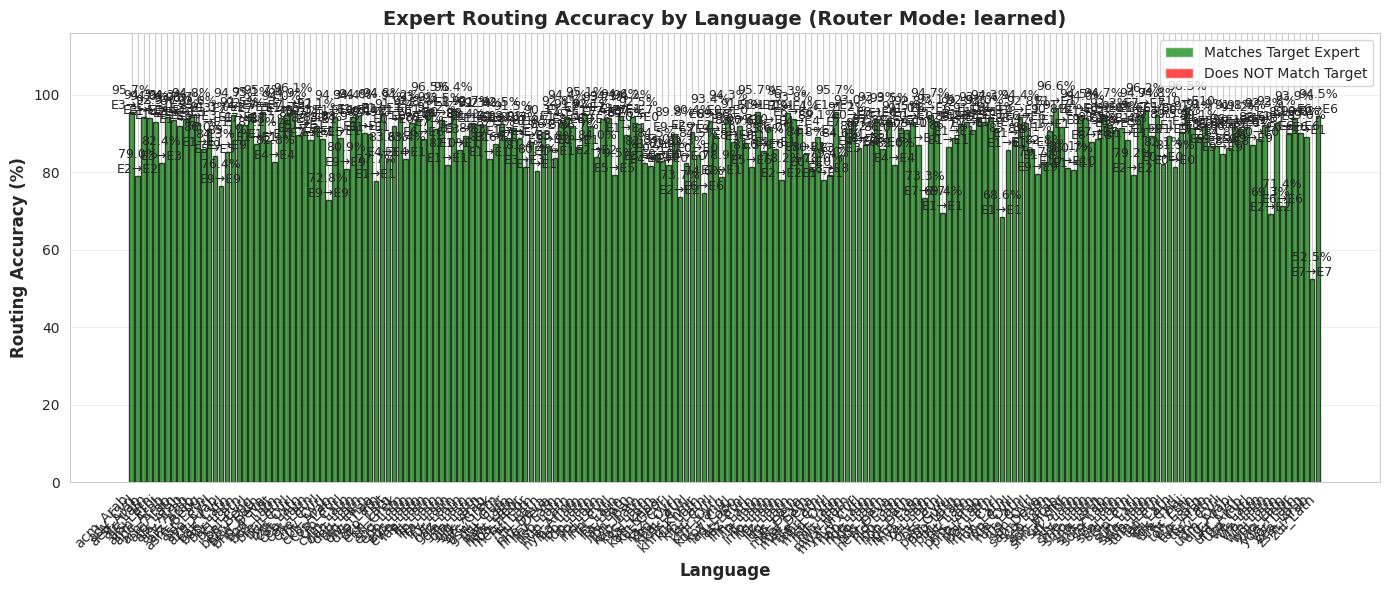

In [16]:
# Bar chart of accuracy by language
fig, ax = plt.subplots(figsize=(14, 6))

languages = [r['language'] for r in results]
accuracies = [r['overall_accuracy'] for r in results]
colors = ['green' if r['matches_target'] else 'red' for r in results]

bars = ax.bar(languages, accuracies, color=colors, alpha=0.7, edgecolor='black')

# Add value labels on bars
for i, (bar, result) in enumerate(zip(bars, results)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f"{result['overall_accuracy']:.1f}%\nE{result['target_expert']}→E{result['most_used_expert']}",
            ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Language', fontsize=12, fontweight='bold')
ax.set_ylabel('Routing Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title(f'Expert Routing Accuracy by Language (Router Mode: {router_mode})', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(accuracies) * 1.2)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Matches Target Expert'),
    Patch(facecolor='red', alpha=0.7, label='Does NOT Match Target')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

## Visualization: Expert Usage Heatmap

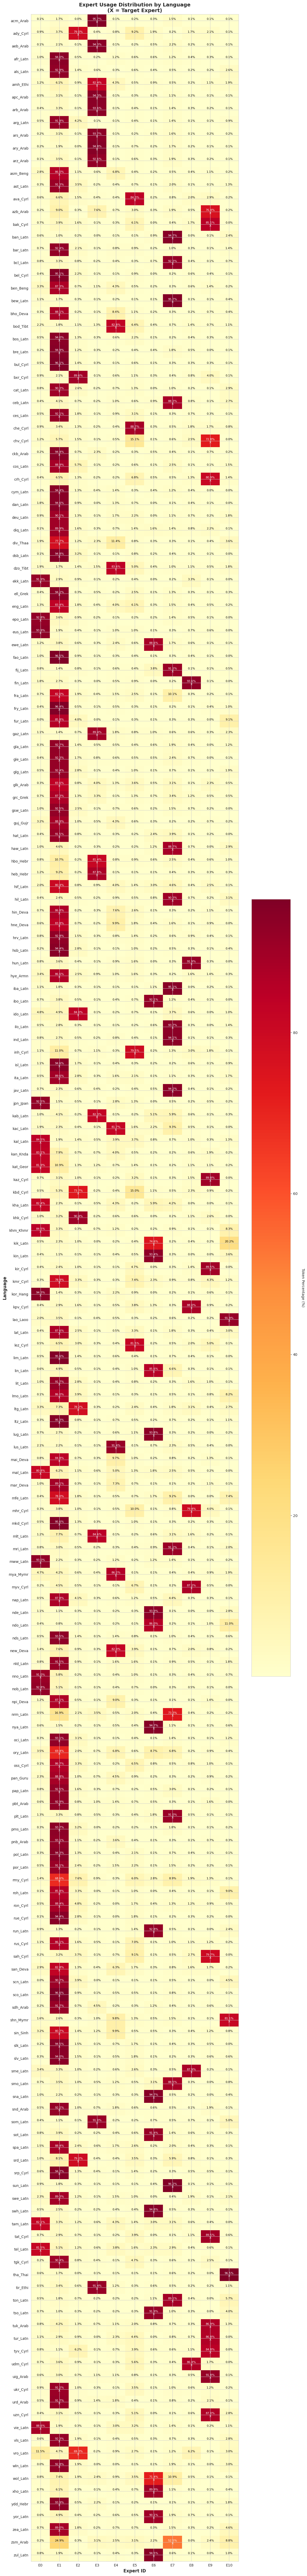

In [19]:
# Create expert usage matrix
expert_usage_matrix = np.zeros((len(results), num_experts))
for i, result in enumerate(results):
    total = result['total_tokens']
    for expert_id, usage in enumerate(result['expert_usage']):
        expert_usage_matrix[i, expert_id] = (usage / total * 100) if total > 0 else 0

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, max(8, len(results) * 0.5)))

im = ax.imshow(expert_usage_matrix, cmap='YlOrRd', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(num_experts))
ax.set_yticks(np.arange(len(results)))
ax.set_xticklabels([f'E{i}' for i in range(num_experts)])
ax.set_yticklabels([r['language'] for r in results])

# Add text annotations
for i, result in enumerate(results):
    target_expert = result['target_expert']
    for j in range(num_experts):
        text_color = 'white' if expert_usage_matrix[i, j] > 50 else 'black'
        marker = 'X' if j == target_expert else ''
        text = f"{expert_usage_matrix[i, j]:.1f}%\n{marker}"
        ax.text(j, i, text, ha="center", va="center", color=text_color, fontsize=8)

ax.set_xlabel('Expert ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Language', fontsize=12, fontweight='bold')
ax.set_title('Expert Usage Distribution by Language\n(X = Target Expert)', 
             fontsize=14, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Token Percentage (%)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

## Visualization: Per-Layer Accuracy

/tmp/ipykernel_3564433/404164432.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


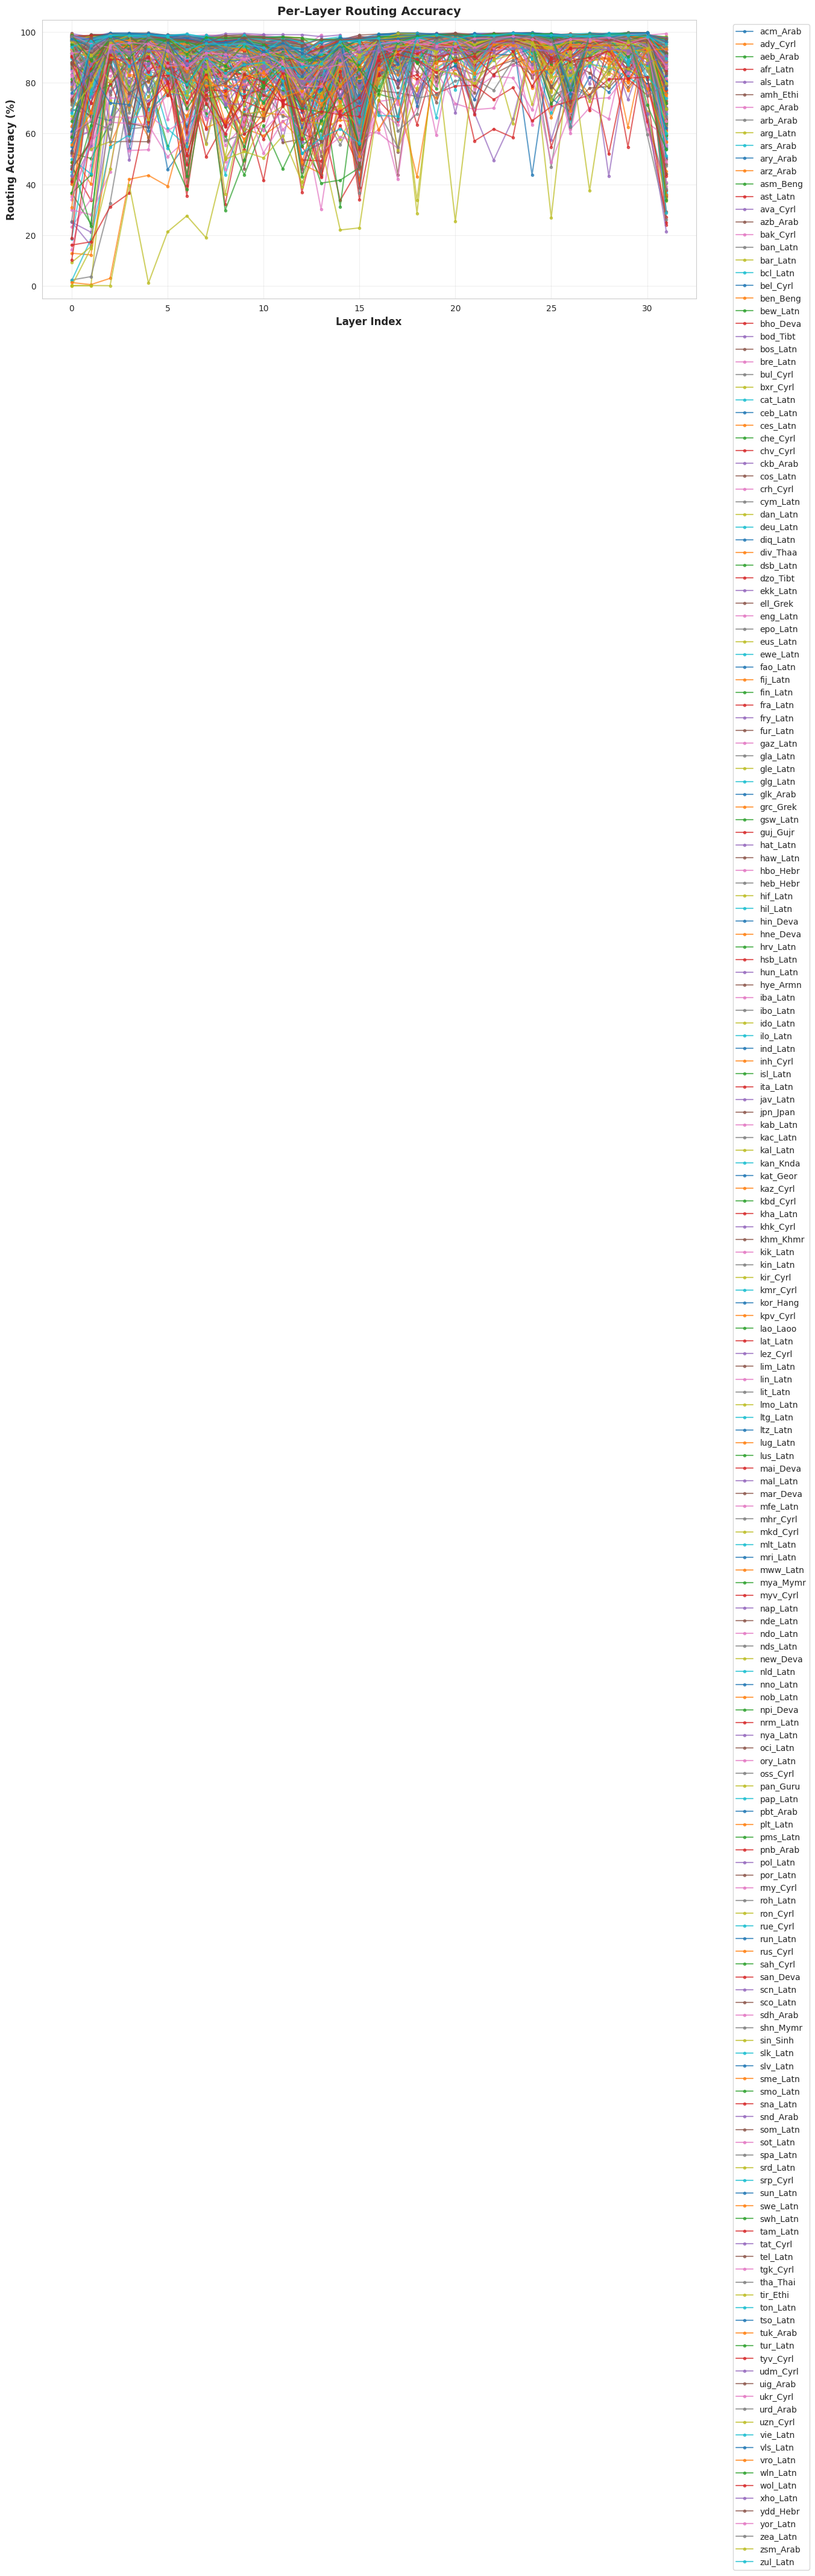

In [20]:
# Plot per-layer accuracy for each language
fig, ax = plt.subplots(figsize=(14, 6))

for result in results:
    ax.plot(range(num_layers), result['per_layer_accuracy'], 
            marker='o', markersize=3, label=result['language'], alpha=0.7)

ax.set_xlabel('Layer Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Routing Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Per-Layer Routing Accuracy', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()